## **Лабороторная работа "Проверка статистических гипотез"**

**Задание:** Используем набор данных Ames Housing.

Сравниваем цены домов (SalePrice) в двух группах.
Группы определяются по значениям количественных переменных.

Для примера используем переменную площадь дома (Gr Liv Area).
Группы определяются условием значение переменной Gr Liv Area больше медианы или
значение переменной Gr Liv Area меньше медианы.

Выбрать гипотезу для проверки.
Либо гипотезу о равенстве математических ожиданий или гипотезу о равенстве медиан.

Обосновать выбор.
Проверить гипотезу.
Проиллюстрировать результат ящиком с усами.

Самостоятельно выбрать две переменные,
то есть сравнение производим ДВАЖДЫ, для двух разных переменных.
В качестве группирующей переменной нельзя использовать переменные SalePrice и Gr Liv Area.

**Описание датасета:** Набор данных содержит информацию из офиса оценщика Ames, которая использовалась при расчете оценочной стоимости отдельных жилых объектов, проданных в  Ames, штат Айова, с 2006 по 2010 год.

**Описание переменных:**
Данные содержат 82 столбца, которые включают 23 номинальных, 23 порядковых, 14 дискретных и 20 непрерывных переменных (и 2 дополнительных идентификатора наблюдений).

In [ ]:
# Импортируем необходимые для работы библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu

In [ ]:
# Загружаем данные
!gdown 1krdy7vs4aVsmG6PXxBddLhCrp1AEuFh5
!unzip AmesHousing.zip

Downloading...
From: https://drive.google.com/uc?id=1krdy7vs4aVsmG6PXxBddLhCrp1AEuFh5
To: /content/AmesHousing.zip
100% 183k/183k [00:00<00:00, 91.3MB/s]
Archive:  AmesHousing.zip
  inflating: AmesHousing.txt         


In [ ]:
# Считываем данные в датафрейм
df = pd.read_csv('AmesHousing.txt', sep='\t')
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [ ]:
# Выведем подробную информацию о датасете (типы данных, пропуски)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
# Посмотрим описательные статистики
df.describe(include=[np.number])

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


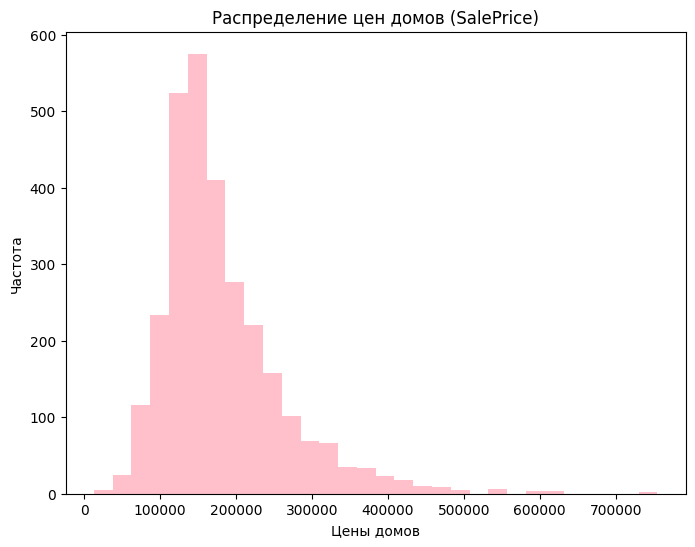

In [ ]:
# Построим гистограмму по переменной SalePrice
plt.figure(figsize=(8,6))
plt.hist(df['SalePrice'], bins=30, color = 'pink')
plt.xlabel('Цены домов')
plt.ylabel('Частота')
plt.title('Распределение цен домов (SalePrice)')
plt.show()

Можно отметить, что распределение не является симметричным, наблюдается положительная скошенность.

Большая часть цен за дома сосредоточена в диапазоне ~100000-250000, но также наблюдается небольшое число домов с аномально высокими ценами.

Переменные, по которым будем проводить сравнение:

| Название столбца | Описание |
|------------------|-----------|
| **Overall Cond** | Общее состояние. Оценка общего состояния дома |
| **Year Built** | Год постройки. Первоначальная дата постройки |

#### **Overoll Cond**

In [ ]:
# Найдем медиану Overall Cond
median_oc = df['Overall Cond'].median()
print(median_oc)

5.0


In [ ]:
# Разделим на две группы
high = df[df['Overall Cond'] > median_oc]['SalePrice']
low = df[df['Overall Cond'] <= median_oc]['SalePrice']

high.name, low.name = 'больше медианного значения', 'ниже или равно медианному значению'

print(f'Длина первой группы (больше медианного значения): {len(high)}')
print(f'Длина второй группы (ниже или равно медианному значению): {len(low)}')

Длина первой группы (больше медианного значения): 1108
Длина второй группы (ниже или равно медианному значению): 1822


Проверка нормальноости распределения

In [ ]:
def two_histograms(x, y, bins=30):
    plt.figure(figsize=(8,6))

    plt.hist(x, bins=bins, alpha=0.5, density=True)
    plt.hist(y, bins=bins, alpha=0.5, density=True)

    plt.axvline(x.median(), color = 'red', linestyle='dashed', linewidth=2)
    plt.axvline(y.median(), color = 'blue', linestyle='dashed', linewidth=2)

    plt.xlabel('Цены домов (SalePrice)')
    plt.ylabel('Частота')
    plt.title('Распределение цен домов в двух группах')
    plt.legend([x.name, y.name])

    plt.show()

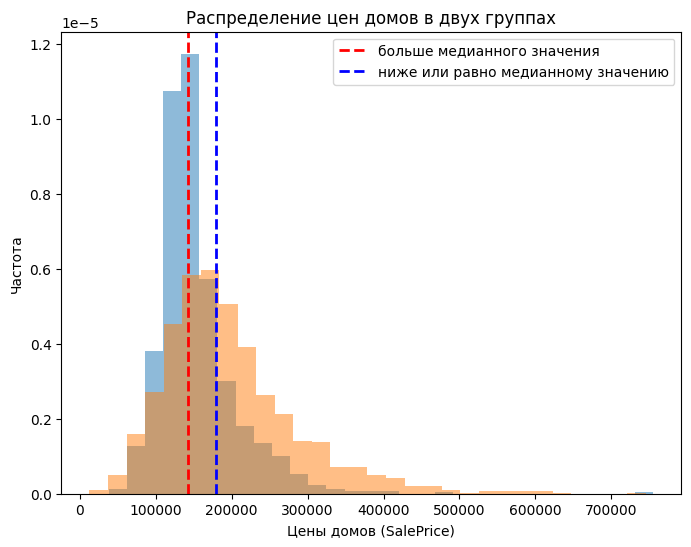

In [ ]:
two_histograms(high, low)

Обе группы демонстрируют положительную скошенность, есть заметные выбросы (небольшое количество домов с очень высокими ценами).

Используем критерий Шапиро-Уилка для проверки гипотезы о нормальном распределении данных (на уровне значимости $0.05$).

$H_0:$ ряд имеет нормальное распределение

$H_1:$ ряд не нормально распределен

In [ ]:
res_high = stats.shapiro(high)
print('Для переменной high (больше медианного значения) p-value: ', res_high[1])

res_low = stats.shapiro(low)
print('Для переменной low (меньше или равно медианному значению) p-value: ', res_low[1])

Для переменной high (больше медианного значения) p-value:  1.3151354900808168e-32
Для переменной low (меньше или равно медианному значению) p-value:  1.2097067223022338e-30


Полученные результаты демонстрируют, что распределение в обеих группах сильно отличается от нормального.

Попробуем применить логарифмирование.

In [ ]:
res_high_log = stats.shapiro(np.log10(high))
print('Для переменной high (больше медианного значения) p-value после логарифмирования: ', res_high_log[1])

res_low_log = stats.shapiro(np.log10(low))
print('Для переменной low (меньше или равно медианному значению) p-value после логарифмирования: ', res_low_log[1])

Для переменной high (больше медианного значения) p-value после логарифмирования:  4.175161254411455e-13
Для переменной low (меньше или равно медианному значению) p-value после логарифмирования:  6.398569048400166e-12


После логарифмирования распределение в обеих группах все еще нельзя назвать нормальным, поэтому мы отвергаем гипотезу $H_0$. В таком случае мы не можем использовать критерий Стьюдента, поэтому используем непараметрический критерий Манна-Уитни (гипотеза о равенстве медиан).

$H_0:$ медианы равны

$H_1:$ медианы не равны

In [ ]:
res_overoll_cond = stats.mannwhitneyu(high, low)
print(res_overoll_cond)

MannwhitneyuResult(statistic=np.float64(672124.5), pvalue=np.float64(4.224153280400293e-52))


$p-value < 0.05$, гипотеза $H_0$ отвергается, медианы не равны.

Распределения цен в группах домов с различной оценкой общего состояния статистически различаются.

Проиллюстрируем результат с помощью графика ящик с усами.

/tmp/ipykernel_437/3578931039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Группы', y='Цены домов (SalePrice)', data=overoll_cond_plot, palette="Set2")


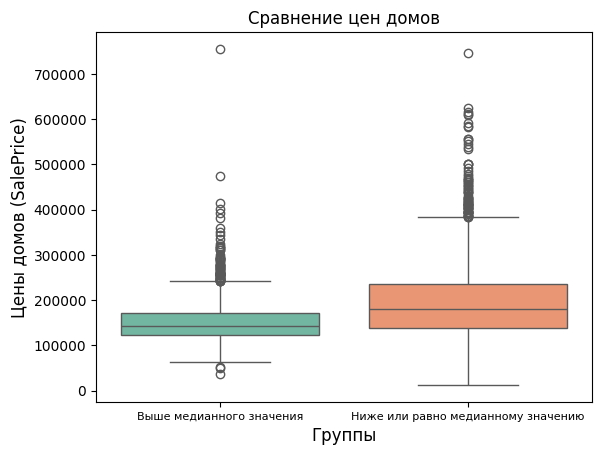

In [ ]:
overoll_cond_plot = pd.DataFrame({'Цены домов (SalePrice)': pd.concat([high, low]),
    'Группы': ['Выше медианного значения']*len(high) + ['Ниже или равно медианному значению']*len(low)})

sns.boxplot(x='Группы', y='Цены домов (SalePrice)', data=overoll_cond_plot, palette="Set2")

plt.xticks(fontsize=8)   # размер шрифта по оси X
plt.xlabel('Группы', fontsize=12)
plt.ylabel('Цены домов (SalePrice)', fontsize=12)
plt.title('Сравнение цен домов', fontsize=12)

plt.show()

In [ ]:
print("Median high:", high.median())
print("Median low:", low.median())

Median high: 142050.0
Median low: 180000.0


**Вывод:** Полученные результаты демонстрируют на первый взгляд необычные результаты: дома, у которых общее состояние зафиксировано выше медианного, стоят дешевле, чем те, у которых общее состояние ниже. Такой результат объясняется тем, что переменная Overall Cond отражает степень сохранности дома, а не его качество или класс, которые, как правильно, сильнее влияют на цену. То есть дом более старого года постройки может хорошо сохраниться (и оценка состояния у него будет высокая), но при этом цена невысокая засчет, например, маленькой стоимости.

Так группа 1, где значения выше медианных, сожержит скорее всего много старых, но хорошо сохранившихся домов, в то время как группа 2, где значения ниже или равны медианным, содержит новые дорогие дома.

#### **Year Built**

In [ ]:
# Найдем медиану Year Built
median_yb = df['Year Built'].median()
print(median_yb)

1973.0


In [ ]:
# Разделим на две группы
high_yb = df[df['Year Built'] > median_yb]['SalePrice']
low_yb = df[df['Year Built'] <= median_yb]['SalePrice']

high_yb.name, low_yb.name = 'больше медианного значения', 'ниже или равно медианному значению'

print(f'Длина первой группы (больше медианного значения): {len(high_yb)}')
print(f'Длина второй группы (ниже или равно медианному значению): {len(low_yb)}')

Длина первой группы (больше медианного значения): 1459
Длина второй группы (ниже или равно медианному значению): 1471


Проверка нормальноости распределения

In [ ]:
def two_histograms(x, y, bins=30):
    plt.figure(figsize=(8,6))

    plt.hist(x, bins=bins, alpha=0.5, density=True)
    plt.hist(y, bins=bins, alpha=0.5, density=True)

    plt.axvline(x.median(), color = 'red', linestyle='dashed', linewidth=2)
    plt.axvline(y.median(), color = 'blue', linestyle='dashed', linewidth=2)

    plt.xlabel('Цены домов (SalePrice)')
    plt.ylabel('Частота')
    plt.title('Распределение цен домов в двух группах')
    plt.legend([x.name, y.name])

    plt.show()

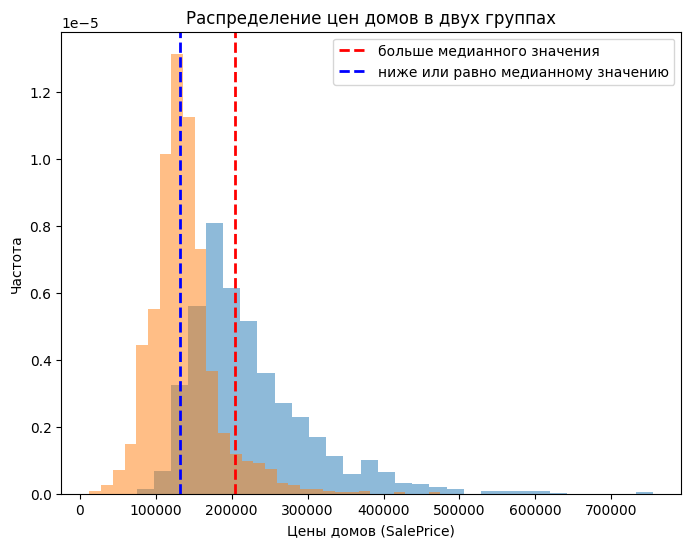

In [ ]:
two_histograms(high_yb, low_yb)

Обе группы демонстрируют положительную скошенность, есть заметные выбросы (небольшое количество домов с очень высокими ценами).

Используем критерий Шапиро-Уилка для проверки гипотезы о нормальном распределении данных (на уровне значимости $0.05$).

$H_0:$ ряд имеет нормальное распределение

$H_1:$ ряд не нормально распределен

In [ ]:
res_high_yb = stats.shapiro(high_yb)
print('Для переменной high_yb (больше медианного значения) p-value: ', res_high_yb[1])

res_low_yb = stats.shapiro(low_yb)
print('Для переменной low_yb (меньше или равно медианному значению) p-value: ', res_low_yb[1])

Для переменной high_yb (больше медианного значения) p-value:  5.5590694772912565e-33
Для переменной low_yb (меньше или равно медианному значению) p-value:  1.2299631350884819e-29


Полученные результаты демонстрируют, что распределение в обеих группах сильно отличается от нормального.

Попробуем применить логарифмирование.

In [ ]:
res_high_yb_log = stats.shapiro(np.log10(high_yb))
print('Для переменной high_yb (больше медианного значения) p-value после логарифмирования: ', res_high_yb_log[1])

res_low_yb_log = stats.shapiro(np.log10(low_yb))
print('Для переменной low_yb (меньше или равно медианному значению) p-value после логарифмирования: ', res_low_yb_log[1])

Для переменной high_yb (больше медианного значения) p-value после логарифмирования:  1.0137222668575805e-12
Для переменной low_yb (меньше или равно медианному значению) p-value после логарифмирования:  5.385583413690542e-22


После логарифмирования распределение в обеих группах все еще нельзя назвать нормальным, поэтому мы отвергаем гипотезу $H_0$. В таком случае мы не можем использовать критерий Стьюдента, поэтому используем непараметрический критерий Манна-Уитни (гипотеза о равенстве медиан).

$H_0:$ медианы равны

$H_1:$ медианы не равны

In [ ]:
res_year_built = stats.mannwhitneyu(high_yb, low_yb)
print(res_year_built)

MannwhitneyuResult(statistic=np.float64(1878713.0), pvalue=np.float64(3.170486907733785e-271))


$p-value < 0.05$, гипотеза $H_0$ отвергается, медианы не равны.

Распределения цен в группах домов с разными годами постройки статистически различаются.

Проиллюстрируем результат с помощью графика ящик с усами.

/tmp/ipykernel_437/1936370058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Группы', y='Цены домов (SalePrice)', data=year_built_plot, palette="Set2")


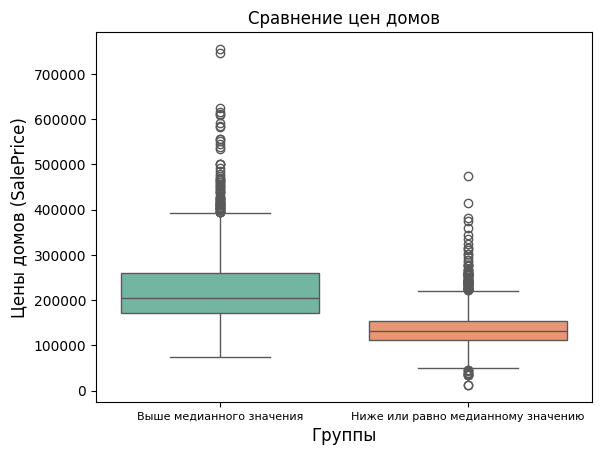

In [ ]:
year_built_plot = pd.DataFrame({'Цены домов (SalePrice)': pd.concat([high_yb, low_yb]),
    'Группы': ['Выше медианного значения']*len(high_yb) + ['Ниже или равно медианному значению']*len(low_yb)})

sns.boxplot(x='Группы', y='Цены домов (SalePrice)', data=year_built_plot, palette="Set2")

plt.xticks(fontsize=8)   # размер шрифта по оси X
plt.xlabel('Группы', fontsize=12)
plt.ylabel('Цены домов (SalePrice)', fontsize=12)
plt.title('Сравнение цен домов', fontsize=12)

plt.show()

**Вывод:** Полученные результаты демонстрируют, что дома с более поздним годом постройки, как правило стоят дороже, чем более старые дома.